# MOABB / PyRiemann Benchmark

Compares multiple BCI pipelines on the MRCP button-press dataset using Leave-One-Trial-Out (LOTO) cross-validation.

| Pipeline | Description |
|---|---|
| **Chance** | Stratified random baseline |
| **CSP + LDA** | Classic motor imagery baseline |
| **MDM** | Minimum Distance to Mean (Riemannian geometry) |
| **TS + LR** | Tangent Space + Logistic Regression |
| **EA + MDM** | Euclidean Alignment → MDM |
| **EA + TS + LR** | Euclidean Alignment → Tangent Space + LR |
| **LGB + Features** | LightGBM on temporal / freq / Hjorth features (existing pipeline) |

**Epoch design** — press: `[-2 s, 0 s]` relative to button onset (captures MRCP buildup); rest: randomly sampled 2 s windows from clean inter-press intervals.

> **Note**: GNG (6.5 s+ inter-press interval) is used by default. SPT has ~1.7 s median IPI which does not leave room for clean 2 s rest windows and is not suitable for epoch-based classification.

In [1]:
import importlib
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

for _pkg in ["moabb", "pyriemann"]:
    if importlib.util.find_spec(_pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)

import os
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mne.decoding import CSP
from pyriemann.classification import MDM
from pyriemann.estimation import Covariances
from pyriemann.preprocessing import Whitening
from pyriemann.tangentspace import TangentSpace
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
import moabb
import pyriemann

from src.preprocessing import load_trial

print(
    f"moabb {moabb.__version__}  pyriemann {pyriemann.__version__}  lightgbm {lgb.__version__}"
)

moabb 1.5.0  pyriemann 0.11  lightgbm 4.6.0


## Configuration

GNG and SPT are the recommended tasks — self-paced button presses with no external visual cue,
so the pre-movement window contains genuine MRCP signal.

**Cue-triggered datasets (MI, WAY) require ERP subtraction** (see `load_subject_epochs`):
- `mi` (BCI Comp IV 2a): fixation-cross onset is the marker; rest epochs bleed into the
  active MI execution period. ERP subtraction cannot fully fix this — MI is **not recommended**.
- `way` (WAY-EEG-GAL): LED fires 360 ms before tHandStart, placing a large VEP inside
  every press epoch. ERP subtraction removes the consistent LED response so only
  trial-to-trial MRCP variation remains.


In [2]:
DATA_ROOT = ROOT / "data"
TACHE = "gng"  # "gng" or "spt" — epoch length auto-adapted to IPI
SUBJECTS = range(10) if TACHE == "spt" else [0]

# Auto-detect sampling rate from first available trial
_first_csv = next((DATA_ROOT / f"subject{SUBJECTS[0]}").glob(f"*{TACHE}*trial_0*"))
_ts = pd.read_csv(_first_csv, sep=None, engine="python", usecols=["timestamp"])[
    "timestamp"
].values
FS_RAW = round(len(_ts) / (_ts[-1] - _ts[0]))
DECIM = 4 if FS_RAW >= 100 else 1
FS_EFF = FS_RAW // DECIM

LP, HP = 0.5, 8.0  # MRCP band
EPOCH_S = 1.5  # seconds before press onset (captures full MRCP ramp)
HORIZON = int(
    1.5 * FS_EFF
)  # samples — anticipatory window (must be clean before press)
REST_RATIO = 3  # max rest epochs per press epoch
SEED = 42

T_EPOCH = int(EPOCH_S * FS_EFF)
print(
    f"FS_RAW={FS_RAW}  DECIM={DECIM}  FS_EFF={FS_EFF}  T_EPOCH={T_EPOCH} ({EPOCH_S:.0f} s)"
)
print(
    f"TACHE={TACHE}  subjects={SUBJECTS}  HORIZON={HORIZON} ({HORIZON/FS_EFF*1000:.0f} ms)"
)

FS_RAW=243  DECIM=4  FS_EFF=60  T_EPOCH=90 (2 s)
TACHE=gng  subjects=[0]  HORIZON=90 (1500 ms)


## Data loading

- **Press epoch**: `[onset − 2 s, onset]` — window ending at press onset, contains MRCP buildup
- **Rest epoch**: 2 s window where the full window AND a task-adaptive post-press buffer contain no press onset
- **Adaptive T**: for tasks with short IPI (e.g. SPT ~2 s), epoch length is auto-reduced to `0.4 × median_IPI`
- **ERP subtraction** (`way` only): the mean press epoch is subtracted from each press epoch
  per trial, removing the consistent LED-evoked VEP. Only trial-specific MRCP variation remains.


In [3]:
def load_subject_epochs(
    subject,
    tache,
    data_root=DATA_ROOT,
    epoch_s=EPOCH_S,
    rest_ratio=REST_RATIO,
    seed=SEED,
):
    """
    Load all trials for one subject → (X, y, groups).

    T and post_buf are derived from the median within-trial IPI so SPT
    (frequent self-paced presses, ~2 s IPI) and GNG (sparse, ~6 s IPI)
    both yield valid rest epochs without manual tuning.

    X      : (n_epochs, n_ch, n_times) — press + rest epochs
    y      : (n_epochs,)  1=press, 0=rest
    groups : (n_epochs,)  trial index for LOTO grouping
    """
    rng = np.random.default_rng(seed)
    subject_dir = data_root / f"subject{subject}"
    trial_files = sorted(subject_dir.glob(f"*{tache}*trial_*.csv"))
    trials = range(5)#sorted({int(p.stem.split("trial_")[1]) for p in trial_files})

    # ── Pass 1: within-trial IPI → adaptive T and post_buf ───────────────────
    all_ipis = []
    for csv_path in trial_files:
        btn = pd.read_csv(csv_path, sep=None, engine="python", usecols=["button"])[
            "button"
        ].values
        onsets = np.where(np.diff(btn.astype(np.int8), prepend=0).clip(0) > 0)[0]
        if len(onsets) > 1:
            all_ipis.extend((np.diff(onsets) / DECIM).tolist())  # → decimated samples

    T_default = int(epoch_s * FS_EFF)
    if all_ipis:
        ipi_med = float(np.median(all_ipis))
        T = min(T_default, max(int(0.3 * FS_EFF), int(0.4 * ipi_med)))
        post_buf = min(HORIZON, int(0.3 * ipi_med))
    else:
        T, post_buf = T_default, HORIZON

    if T < T_default:
        print(
            f"  [auto] subject {subject}: median IPI = {ipi_med / FS_EFF * 1000:.0f} ms → "
            f"epoch = {T / FS_EFF * 1000:.0f} ms, post_buf = {post_buf / FS_EFF * 1000:.0f} ms"
        )

    # ── Pass 2: load epochs ───────────────────────────────────────────────────
    all_X, all_y, all_groups = [], [], []

    for trial in trials:
        df, cols = load_trial(
            subject,
            tache,
            trial,
            str(subject_dir),
            eeg_cols=None,
            fs=FS_RAW,
            lp=LP,
            hp=HP,
            decimate=DECIM,
            car=True,
            trial_zscore=True,
        )
        Xc = df[cols].values.astype(np.float32)  # (N, C)
        y_mom = df["button"].values.astype(np.int8)
        N, C = Xc.shape

        # Press epochs: window ending at press onset
        press_onsets = np.where(y_mom > 0)[0]
        press_onsets = press_onsets[press_onsets >= T]

        # LED-aligned ERP subtraction on the continuous signal (WAY only).
        # Aligning to LED onset gives a sharper VEP template than press-aligned
        # subtraction: VEP latency relative to LED is fixed; MRCP latency varies.
        if tache in ("way",) and "led" in df.columns:
            led_onsets = np.where(df["led"].values > 0)[0]
            valid_led  = led_onsets[(led_onsets + T) < N]
            if len(valid_led) >= 3:
                mean_ep = np.stack([Xc[l : l + T] for l in valid_led]).mean(axis=0)
                Xc = Xc.copy()
                for l in valid_led:
                    Xc[l : l + T] -= mean_ep

        press_eps = [Xc[o - T : o].T for o in press_onsets]   # list of (C, T)

        for ep in press_eps:
            all_X.append(ep)
            all_y.append(1)
            all_groups.append(trial)

        # Rest epochs: forbidden zone = [onset-T, onset+post_buf] per press
        forbidden = np.zeros(N, dtype=bool)
        for onset in np.where(y_mom > 0)[0]:
            forbidden[max(0, onset - T) : min(N, onset + post_buf)] = True

        fconv = np.convolve(
            forbidden.astype(np.float32), np.ones(T, dtype=np.float32), mode="full"
        )[:N]
        valid_ends = np.where(fconv[T:] == 0)[0] + T
        n_rest = min(len(valid_ends), len(press_onsets) * rest_ratio)

        if n_rest == 0:
            print(f"  [warn] subject {subject} trial {trial}: no valid rest windows")
        else:
            chosen = rng.choice(valid_ends, size=n_rest, replace=False)
            for end in chosen:
                all_X.append(Xc[end - T : end].T)  # (C, T)
                all_y.append(0)
                all_groups.append(trial)

    if not all_X:
        print(f"  [warn] subject {subject}: no epochs collected — skipping")
        C_guess = len(cols) if "cols" in dir() else 1
        return (
            np.zeros((0, C_guess, T), dtype=np.float32),
            np.zeros(0, dtype=np.int8),
            np.zeros(0, dtype=np.int32),
        )

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.int8)
    groups = np.array(all_groups, dtype=np.int32)
    n_press = (y == 1).sum()
    n_rest_ = (y == 0).sum()
    print(
        f"  subject {subject}: {len(trials)} trials  "
        f"{n_press} press / {n_rest_} rest  "
        f"T={T} ({T / FS_EFF * 1000:.0f} ms)  ({C} ch × {T} samples)"
    )
    return X, y, groups


print("Loading epochs …")
subject_data = {}
for subj in SUBJECTS:
    X_, y_, g_ = load_subject_epochs(subj, TACHE)
    subject_data[subj] = (X_, y_, g_)

Loading epochs …
  subject 0: 5 trials  128 press / 384 rest  T=90 (1500 ms)  (16 ch × 90 samples)


## Pipeline definitions

In [5]:
# ── Feature extractor for LGB pipeline ───────────────────────────────────────


def _extract_features(X):
    """(n_epochs, n_ch, n_times) → (n_epochs, n_ch×12) temporal + freq + Hjorth."""
    n, c, t = X.shape
    X64 = X.astype(np.float64)

    # Temporal (6 per channel)
    t_c = np.arange(t, dtype=np.float64) - (t - 1) / 2.0
    t_var = (t_c**2).sum() + 1e-12
    feat_t = (
        np.stack(
            [
                X64.mean(-1),
                X64.std(-1),
                (X64 * t_c[None, None, :]).sum(-1) / t_var,
                X64.min(-1),
                X64.argmin(-1) / t,
                np.sqrt((X64**2).mean(-1)),
            ],
            axis=2,
        )
        .reshape(n, c * 6)
        .astype(np.float32)
    )

    # Frequency: delta power, theta power, spectral entropy (3 per channel)
    f, p = welch(X, fs=FS_EFF, nperseg=min(t, 64), axis=-1)
    df_ = f[1] - f[0]
    dp = p[:, :, (f >= 0.5) & (f <= 4.0)].sum(-1) * df_
    tp = p[:, :, (f >= 4.0) & (f <= 8.0)].sum(-1) * df_
    pn = p[:, :, f > 0] / (p[:, :, f > 0].sum(-1, keepdims=True) + 1e-12)
    se = -(pn * np.log(pn + 1e-12)).sum(-1)
    feat_f = np.stack([dp, tp, se], axis=2).reshape(n, c * 3).astype(np.float32)

    # Hjorth: activity, mobility, complexity (3 per channel)
    d1 = np.diff(X, axis=-1)
    d2 = np.diff(d1, axis=-1)
    v0 = X.var(-1) + 1e-12
    v1 = d1.var(-1) + 1e-12
    v2 = d2.var(-1) + 1e-12
    mob = np.sqrt(v1 / v0)
    cmp = np.sqrt(v2 / v1) / (mob + 1e-12)
    feat_h = np.stack([v0, mob, cmp], axis=2).reshape(n, c * 3).astype(np.float32)

    return np.concatenate([feat_t, feat_f, feat_h], axis=1)


# ── EA + MF feature extractor (sklearn transformer) ─────────────────────────
class EAMFFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Per-fold Euclidean Alignment followed by temporal/freq/Hjorth + matched-filter
    features.  Mirrors the focused notebook's lgb_objective fold logic exactly.

    Input  : (n_epochs, n_ch, n_times)   [channels-first epoch format]
    Output : (n_epochs, n_ch * 13)       [12 standard + 1 MF per channel]
    """

    def fit(self, X, y=None):
        n, c, t = X.shape
        X64 = X.astype(np.float64)
        # Covariance per epoch: (n_ch × n_times) × (n_times × n_ch) / t
        covs   = np.einsum("nct,ndt->ncd", X64, X64) / t   # (n, c, c)
        R_mean = covs.mean(axis=0)                          # (c, c)
        from scipy.linalg import sqrtm, inv
        self.W_ = inv(sqrtm(R_mean)).real.astype(np.float32)  # (c, c)

        # EA-align training set, then build MF template from press epochs
        X_ea = np.einsum("cd,ndt->nct", self.W_, X64).astype(np.float32)
        if y is not None and (np.asarray(y) == 1).any():
            self.template_ = X_ea[np.asarray(y) == 1].mean(axis=0)  # (c, t)
        else:
            self.template_ = X_ea.mean(axis=0)
        return self

    def transform(self, X):
        X_ea = np.einsum("cd,ndt->nct", self.W_, X.astype(np.float64)).astype(np.float32)

        # Standard features (12 per channel)
        feats = _extract_features(X_ea)  # (n, c*12)

        # Matched-filter: normalised dot-product with template, per channel
        n, c, t = X_ea.shape
        t_norm = self.template_ / (
            np.linalg.norm(self.template_, axis=-1, keepdims=True) + 1e-12
        )                                                        # (c, t)
        x_norm = X_ea / (
            np.linalg.norm(X_ea, axis=-1, keepdims=True) + 1e-12
        )                                                        # (n, c, t)
        mf = (x_norm * t_norm[None]).sum(axis=-1)               # (n, c)

        return np.concatenate([feats, mf], axis=1)              # (n, c*13)


# ── Pipelines ─────────────────────────────────────────────────────────────────
pipelines = {
    "Chance": make_pipeline(
        FunctionTransformer(_extract_features),
        DummyClassifier(strategy="stratified", random_state=SEED),
    ),
    "CSP+LDA": make_pipeline(
        CSP(n_components=6, log=True, reg="ledoit_wolf"),
        LDA(),
    ),
    "MDM": make_pipeline(
        Covariances("oas"),
        MDM(metric="riemann"),
    ),
    "TS+LR": make_pipeline(
        Covariances("oas"),
        TangentSpace("riemann"),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    ),
    "EA+MDM": make_pipeline(
        Covariances("oas"),
        Whitening(),
        MDM(metric="riemann"),
    ),
    "EA+TS+LR": make_pipeline(
        Covariances("oas"),
        Whitening(),
        TangentSpace("riemann"),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    ),
    "LGB+Features": make_pipeline(
        EAMFFeatureExtractor(),
        lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            verbose=-1,
            n_jobs=-1,
        ),
    ),
}
print(f"{len(pipelines)} pipelines defined.")

7 pipelines defined.


## LOTO benchmark

Leave-One-Trial-Out: train on all trials except one, evaluate on the held-out trial. Repeated for every trial.

In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

TARGET_SPEC = 0.90   # operating specificity for EpochSens

def _sens_at_spec(scores, y, target_spec=TARGET_SPEC):
    """Max epoch sensitivity where epoch-FPR <= 1-target_spec."""
    thresholds = np.sort(np.unique(scores))[::-1]
    n_pos = (y == 1).sum(); n_neg = (y == 0).sum()
    best_sens, best_thresh = 0.0, (float(thresholds[0]) if len(thresholds) else 1.0)
    for thr in thresholds:
        fpr = (scores[y == 0] >= thr).sum() / (n_neg + 1e-12)
        if fpr <= (1 - target_spec):
            sens = (scores[y == 1] >= thr).sum() / (n_pos + 1e-12)
            if sens > best_sens:
                best_sens, best_thresh = sens, float(thr)
    return best_sens, best_thresh

loso    = LeaveOneGroupOut()
records = []

for subj in SUBJECTS:
    X, y, groups = subject_data[subj]
    n_folds = len(np.unique(groups))
    print(
        f"\nSubject {subj}  ({n_folds} folds, {len(X)} epochs) ────────────────────────"
    )
    for name, pipe in pipelines.items():
        try:
            scores = cross_val_predict(
                pipe, X, y, groups=groups, cv=loso,
                method="predict_proba", n_jobs=1,
            )[:, 1]
            auc      = roc_auc_score(y, scores)
            ap       = average_precision_score(y, scores)
            evt_sens, thresh = _sens_at_spec(scores, y)
            print(
                f"  {name:<16}  AUC={auc:.3f}  AP={ap:.3f}  "
                f"EpochSens@Spec{int(TARGET_SPEC*100)}={evt_sens:.1%}"
            )
        except Exception as e:
            auc = ap = evt_sens = thresh = float("nan")
            print(f"  {name:<16}  ERROR: {e}")
        records.append(
            dict(subject=subj, pipeline=name,
                 auc=auc, ap=ap, evt_sens=evt_sens, thresh=thresh)
        )

results = pd.DataFrame(records)



Subject 0  (5 folds, 512 epochs) ────────────────────────
  Chance            AUC=0.449  AP=0.237  EpochSens@Spec90=0.0%
Computing rank from data with rank=None
    Using tolerance 1.6 (2.2e-16 eps * 16 dim * 4.4e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.4 (2.2e-16 eps * 16 dim * 3.9e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.4 (2.2e-16 eps * 16 dim * 3.9e+14  max singular value)
    Estimated rank (data): 16
    data: rank 16 com

## Results

In [7]:
# ── Per-subject table ─────────────────────────────────────────────────────────
pivot_auc = results.pivot_table(
    index="pipeline", columns="subject", values="auc", aggfunc="mean"
).round(3)
pivot_auc["mean"] = pivot_auc.mean(axis=1).round(3)
pivot_auc = pivot_auc.sort_values("mean", ascending=False)

pivot_sens = results.pivot_table(
    index="pipeline", columns="subject", values="evt_sens", aggfunc="mean"
).round(3)
pivot_sens["mean"] = pivot_sens.mean(axis=1).round(3)
pivot_sens = pivot_sens.reindex(pivot_auc.index)   # same row order as AUC table

print(f"LOTO AUC per subject:")
print(pivot_auc.to_string())
print(f"\nEpochSens @ Spec{int(TARGET_SPEC*100)} per subject:")
print(pivot_sens.to_string())


LOTO AUC per subject:
subject           0   mean
pipeline                  
EA+TS+LR      0.721  0.721
TS+LR         0.721  0.721
CSP+LDA       0.701  0.701
LGB+Features  0.701  0.701
EA+MDM        0.657  0.657
MDM           0.657  0.657
Chance        0.449  0.449

EpochSens @ Spec90 per subject:
subject           0   mean
pipeline                  
EA+TS+LR      0.211  0.211
TS+LR         0.211  0.211
CSP+LDA       0.125  0.125
LGB+Features  0.219  0.219
EA+MDM        0.102  0.102
MDM           0.102  0.102
Chance        0.000  0.000


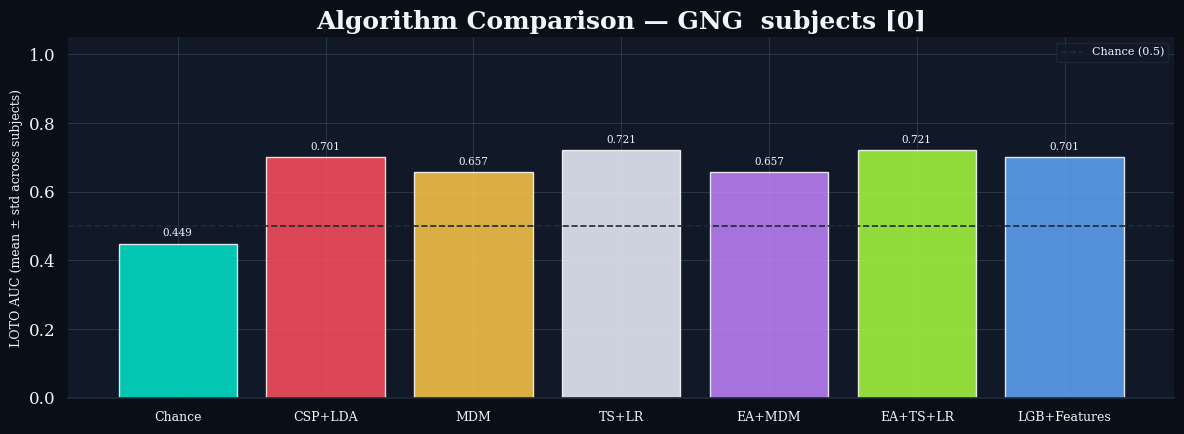

In [8]:
%matplotlib inline

DARK, CARD, EDGE = "#0a0e17", "#111827", "#1f2937"
TEAL, CORAL, GOLD, WHITE = "#00e5cc", "#ff4f5e", "#ffc947", "#f0f4ff"
PALETTE = [TEAL, CORAL, GOLD, WHITE, "#c084fc", "#a8ff3e", "#60a5fa"]

pipeline_order = list(pipelines.keys())
agg = (
    results.groupby("pipeline")
    .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"))
    .loc[pipeline_order]
)

fig, ax = plt.subplots(figsize=(12, 4.5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

xs = np.arange(len(pipeline_order))
bars = ax.bar(
    xs,
    agg["auc_mean"],
    yerr=agg["auc_std"],
    color=PALETTE[: len(pipeline_order)],
    alpha=0.85,
    capsize=4,
    error_kw=dict(ecolor=WHITE, lw=1.2),
)
ax.axhline(0.5, color=EDGE, lw=1.2, ls="--", label="Chance (0.5)")

ax.set_xticks(xs)
ax.set_xticklabels(pipeline_order, color=WHITE, fontsize=9)
ax.set_ylabel("LOTO AUC (mean ± std across subjects)", color=WHITE, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title(
    f"Algorithm Comparison — {TACHE.upper()}  subjects {SUBJECTS}",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)

for bar, val in zip(bars, agg["auc_mean"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        color=WHITE,
        fontsize=7.5,
    )

plt.tight_layout()
os.makedirs("report", exist_ok=True)
plt.savefig("report/moabb_benchmark.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()

In [9]:
import pickle
from sklearn.base import clone

SAVE_DIR   = ROOT / "notebooks" / "models"
SMOOTH_WIN = max(1, int(0.1 * FS_EFF))   # 100 ms causal smoothing
REFRACTORY = int(0.5 * FS_EFF)            # 500 ms dead-band after detection
PERSIST_K  = 1

# Best pipeline by mean AUC across subjects
best_name = agg["auc_mean"].idxmax()
best_auc  = float(agg.loc[best_name, "auc_mean"])
print(f"Best pipeline : {best_name}  (mean AUC = {best_auc:.3f})")
print()

saved = []
for subj in SUBJECTS:
    X, y, groups = subject_data[subj]
    T_actual = int(X.shape[-1])   # may differ from T_EPOCH if IPI-adaptive

    # Channel names from first trial CSV
    _csv = next((DATA_ROOT / f"subject{subj}").glob(f"*{TACHE}*trial_0*"))
    _df  = pd.read_csv(_csv, sep=None, engine="python", nrows=1)
    eeg_cols = [c for c in _df.columns
                if c not in ("timestamp", "button", "label")]

    # Refit best pipeline on all available data for this subject
    pipe = clone(pipelines[best_name])
    pipe.fit(X, y)

    # Threshold at TARGET_SPEC (mean of per-trial values from CV)
    cv_thresh = results.loc[
        (results.subject == subj) & (results.pipeline == best_name), "thresh"
    ].mean()
    thresh = float(cv_thresh) if not np.isnan(cv_thresh) else 0.5

    payload = {
        # identity
        "pipeline_name": best_name,
        "pipeline":      pipe,          # full sklearn pipeline for batch prediction
        "tache":         TACHE,
        "subject":       subj,
        # preprocessing config (matches load_trial calls in load_subject_epochs)
        "FS":            FS_RAW,
        "DECIM":         DECIM,
        "FS_EFF":        FS_EFF,
        "LP":            LP,
        "HP":            HP,
        "T_OPT":         T_actual,
        "HORIZON":       HORIZON,
        "SMOOTH_WIN":    SMOOTH_WIN,
        "REFRACTORY":    REFRACTORY,
        "PERSIST_K":     PERSIST_K,
        "thresh":        thresh,
        "EEG_COLS":      eeg_cols,
        # evaluation summary
        "auc_cv":        best_auc,
        "evt_sens_cv":   float(
            results.loc[
                (results.subject == subj) & (results.pipeline == best_name),
                "evt_sens",
            ].mean()
        ),
    }

    # For LGB+Features: also store W and the raw classifier separately so
    # evaluate_trial.py can load them (note: it expects 12×C features; this
    # pipeline outputs 13×C with the matched-filter column appended).
    if best_name == "LGB+Features":
        extractor  = pipe.steps[0][1]   # EAMFFeatureExtractor
        classifier = pipe.steps[-1][1]  # LGBMClassifier
        payload["W"]     = extractor.W_.astype(np.float64)
        payload["model"] = classifier

    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    out = SAVE_DIR / f"moabb_{TACHE}_s{subj}.pkl"
    with open(out, "wb") as fh:
        pickle.dump(payload, fh)
    saved.append(out)
    print(
        f"  s{subj}: {out.name}  "
        f"T_OPT={T_actual} ({T_actual / FS_EFF * 1000:.0f} ms)  "
        f"thresh={thresh:.4f}  "
        f"AUC_CV={best_auc:.3f}"
    )

print(f"\nSaved {len(saved)} model(s) → {SAVE_DIR}")
if best_name == "LGB+Features":
    print(
        "\nNote: evaluate_trial.py expects 12×C features (no matched-filter column).\n"
        "Pass --model notebooks/models/moabb_{TACHE}_s{subj}.pkl after adapting\n"
        "evaluate_trial.py to also compute the MF feature, or use the 'pipeline'\n"
        "key directly for batch epoch prediction."
    )


Best pipeline : EA+TS+LR  (mean AUC = 0.721)

  s0: moabb_gng_s0.pkl  T_OPT=90 (1500 ms)  thresh=0.9284  AUC_CV=0.721

Saved 1 model(s) → /Users/vinicius/Documents/EEG/notebooks/models
